# Interpretability & Reporting

This notebook brings together the findings from the EDA and modeling notebooks into a final narrative:

1. **Project Summary:** Overall results across all experiments.
2. **EEG Signal Processing:** Methodology, justification, and possible alternatives.
3. **SHAP Feature Importance:** We identifie which features drive classification.
4. **SHAP Topographic Projection:** Where in the brain the signal comes from.
5. **Gate Value Analysis**  How our model weights each modality per subject, and it's relevance.
6. **Hypotheses Validation** Evaluation of our H1, H2, H3
7. **Conclusions & Limitations**

In [ ]:
#Libraries 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import mne
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score
from scipy import stats
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Format Plots
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'RD': '#4C72B0', 'MD': '#DD8452'}
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,'axes.spines.right': False})

#SEED
RANDOM  = 42

Setup complete. Models re-fitted for SHAP.
EEG SVM  AUC=0.555 | Psycho SVM AUC=0.501 | Fusion AUC=0.604


In [20]:
#Paths
ROOT = Path('C:/Users/diego/Desktop/multimodal-neucog')
PROC = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# We load our data and re-fit our best models on the full dataset for SHAP interpretation.


# Load data
psycho = pd.read_csv(PROC / 'psycho_features_pre.csv')
eeg = pd.read_csv(PROC / 'eeg_features_pre.csv')
gates = pd.read_csv(PROC / 'gate_values.csv')

#Features
EEG_COLS = [c for c in eeg.columns if c.startswith('baseline_')]
SHARED_COLS = ['IQ', 'selective_attention', 'age']
BANDS = ['delta','theta','alpha','beta']
REGIONS = ['frontal','frontocentral','central','centroparietal','temporal','parietal','occipital']

#We merge the datasets 
df = pd.merge(eeg[['subject_id','label']+EEG_COLS],psycho[['subject_id']+SHARED_COLS], on='subject_id').dropna()

#Encode labels
le = LabelEncoder()
y  = le.fit_transform(df['label'])
X_eeg    = df[EEG_COLS].values
X_shared = df[SHARED_COLS].values

#CV
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM)

# Re-run best models for SHAP
RF  = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, random_state=RANDOM)
SVM = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM)
sc = StandardScaler()
X_sc = sc.fit_transform(X_eeg)
RF.fit(X_sc, y)

# CV predictions for metrics
def get_metrics(X, clf, name):
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    y_pred = cross_val_predict(pipe, X, y, cv=CV, method='predict')
    y_prob = cross_val_predict(pipe, X, y, cv=CV, method='predict_proba')[:, 1]
    
    return {'name': name,
            'auc': roc_auc_score(y, y_prob),
            'bal': balanced_accuracy_score(y, y_pred),
            'acc': accuracy_score(y, y_pred)}

m_eeg = get_metrics(X_eeg, SVC(kernel='rbf', probability=True, random_state=RANDOM), 'EEG Only')
m_psy = get_metrics(X_shared, SVC(kernel='rbf', probability=True, random_state=RANDOM), 'Shared Psycho')

# Fusion metrics from gate_values
y_full = (gates['label']=='RD').astype(int).values
auc_f = roc_auc_score(y_full, gates['fusion_prob'])
bal_f = balanced_accuracy_score(y_full, (gates['fusion_prob']>=0.5).astype(int))
m_fus = {'name':'Fusion (Gate)', 'auc': auc_f, 'bal': bal_f}

print(f"EEG SVM  AUC={m_eeg['auc']:.3f} | Psycho SVM AUC={m_psy['auc']:.3f} | Fusion AUC={m_fus['auc']:.3f}")

EEG SVM  AUC=0.555 | Psycho SVM AUC=0.501 | Fusion AUC=0.604


## 1. Project Summary

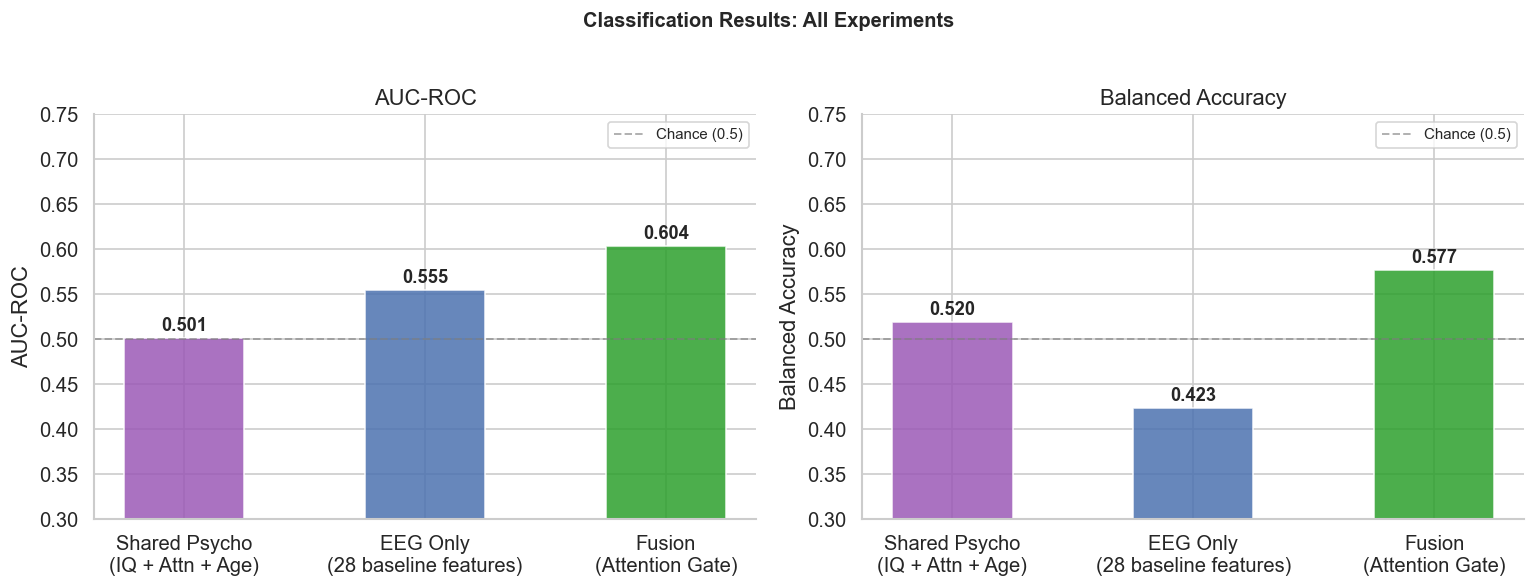


Fusion gain over EEG: ++0.049 AUC
Fusion gain over Psycho: ++0.102 AUC


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Classification Results: All Experiments\n',fontsize=12, fontweight='bold')

# Results
exps = [
    ('Shared Psycho\n(IQ + Attn + Age)', m_psy['auc'], m_psy['bal'], '#9B59B6', False),
    ('EEG Only\n(28 baseline features)', m_eeg['auc'], m_eeg['bal'], '#4C72B0', False),
    ('Fusion\n(Attention Gate)', m_fus['auc'], m_fus['bal'], '#2ca02c', False),
]

names = [e[0] for e in exps]
aucs = [e[1] for e in exps]
bals = [e[2] for e in exps]
cols = [e[3] for e in exps]

# AUC bar
ax = axes[0]
bars = ax.bar(names, aucs, color=cols, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.6, label='Chance (0.5)')
ax.set_ylim(0.3, 0.75); ax.set_ylabel('AUC-ROC'); ax.set_title('AUC-ROC')
ax.legend(fontsize=9)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.008, f'{val:.3f}',
            ha='center', fontsize=11, fontweight='bold')

# Balanced accuracy bar
ax2 = axes[1]
bars2 = ax2.bar(names, bals, color=cols, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.6, label='Chance (0.5)')
ax2.set_ylim(0.3, 0.75); ax2.set_ylabel('Balanced Accuracy'); ax2.set_title('Balanced Accuracy')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, bals):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.008, f'{val:.3f}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR/'15_summary_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nFusion gain over EEG: +{m_fus["auc"]-m_eeg["auc"]:+.3f} AUC')
print(f'Fusion gain over Psycho: +{m_fus["auc"]-m_psy["auc"]:+.3f} AUC')


## 2. EEG Signal Processing Methodology

This section documents the feature extraction pipeline applied to the raw EEG recordings.

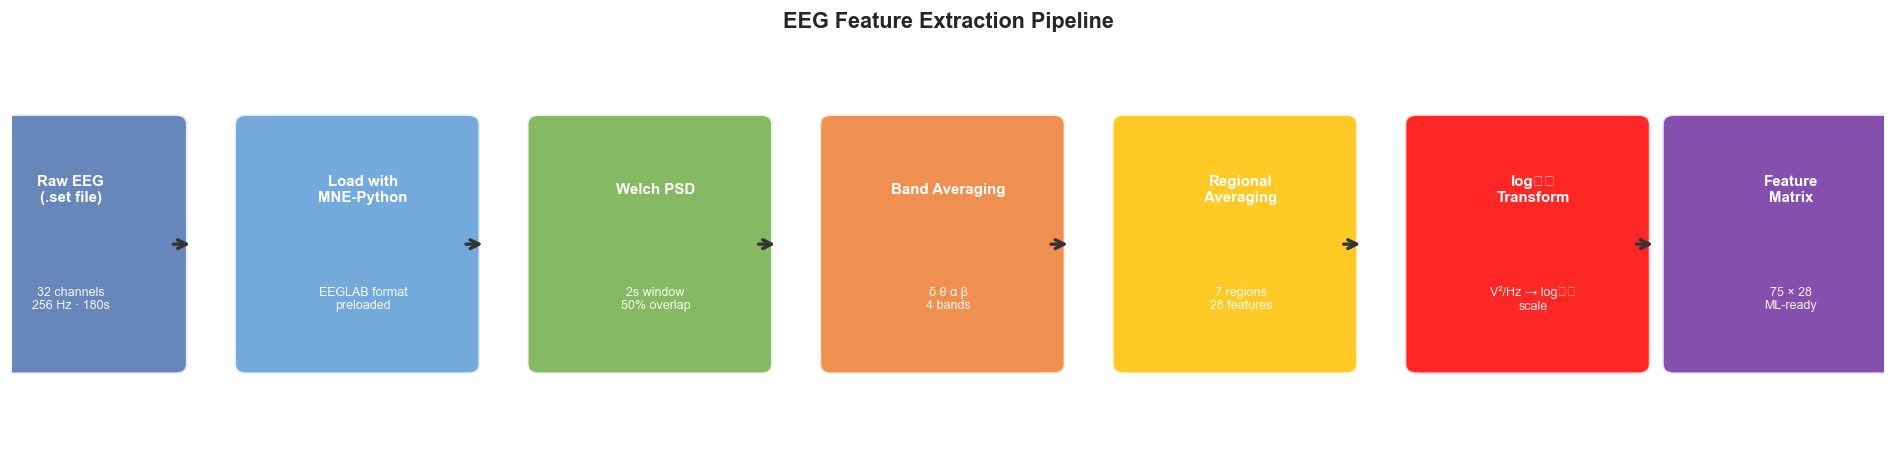

In [26]:
#Flow Diagram
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16); ax.set_ylim(0, 4); ax.axis('off')
fig.patch.set_facecolor('white')

steps = [
    (0.5,  'Raw EEG\n(.set file)',        '32 channels\n256 Hz · 180s',   '#4C72B0'),
    (3.0,  'Load with\nMNE-Python',       'EEGLAB format\npreloaded',     '#5B9BD5'),
    (5.5,  'Welch PSD',                   '2s window\n50% overlap',       '#70AD47'),
    (8.0,  'Band Averaging',              'δ θ α β\n4 bands',             '#ED7D31'),
    (10.5, 'Regional\nAveraging',         '7 regions\n28 features',       '#FFC000'),
    (13.0, 'log₁₀\nTransform',           'V²/Hz → log₁₀\nscale',        '#FF0000'),
    (15.2, 'Feature\nMatrix',            '75 × 28\nML-ready',            '#7030A0'),
]

for x, title, subtitle, color in steps:
    box = mpatches.FancyBboxPatch((x-1.0, 0.8), 1.9, 2.4,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, edgecolor='white',
                                   alpha=0.85, linewidth=2)
    ax.add_patch(box)
    ax.text(x, 2.55, title, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', wrap=True)
    ax.text(x, 1.45, subtitle, ha='center', va='center', fontsize=7.5,
            color='white', alpha=0.92)

# Arrows
arrow_xs = [1.4, 3.9, 6.4, 8.9, 11.4, 13.9]
for ax_x in arrow_xs:
    ax.annotate('', xy=(ax_x+0.15, 2.0), xytext=(ax_x-0.05, 2.0),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=2))

ax.set_title('EEG Feature Extraction Pipeline', fontsize=13,
             fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR/'16_eeg_pipeline.png', bbox_inches='tight', dpi=150)
plt.show()

The raw EEG signal for one subject contains **32 channels × 46,080 time points = 1.47 million values**. If we feed this directly into a classifier with n=75 subjects is not feasible. A feature extraction reduces this to a compact, interpretable representation.

The Welch method segments the signal into overlapping 2-second windows, computes the FFT of each,
and averages the resulting spectra. This produces a stable estimate of power at each frequency.
Band averaging then summarises each frequency range (delta, theta, alpha, beta) into a single value
per channel, and regional averaging pools channels within anatomically defined regions.

The key tradeoff: band power loses temporal dynamics within the recording window and assumes
approximate stationarity over the 3-minute baseline. A more sophisticated approach could extract
power in sliding windows and capture temporal variability, but this multiplies the feature count
and overfitting risk substantially. For n=75, the chosen approach represents the optimal
balance between information content and statistical stability.

## 3. SHAP Feature Importance

SHAP quantifies the contribution of each feature to the model's prediction for every individual subject. SHAP shows both the magnitude and direction of each feature's influence:
positive SHAP = pushes toward MD, negative SHAP = pushes toward RD.

In [30]:
# Compute SHAP values
explainer   = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_sc)

# Helper for dimensionality 
if isinstance(shap_values, list):
    sv_md = shap_values[1]              # old: list[class_idx] to (75, 28)
elif shap_values.ndim == 3:
    sv_md = shap_values[:, :, 1]       # new: (75, 28, 2) to (75, 28)
else:
    sv_md = shap_values                 # single output regression


# Clean feature names for display
feat_names = [f.replace('baseline_','').replace('_',' ').title() for f in EEG_COLS]
print(f'SHAP values shape: {sv_md.shape}')
print(f'Features: {len(feat_names)}')

# Mean absolute SHAP per feature
mean_abs_shap = np.abs(sv_md).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1]
print('\nTop 10 features by mean SHAP:\n')
for i in top_idx[:10]:
    print(f'  {feat_names[i]:}: {mean_abs_shap[i]:.4f}')

SHAP values shape: (75, 28)
Features: 28

Top 10 features by mean SHAP:

  Parietal Theta: 0.0246
  Occipital Delta: 0.0176
  Occipital Theta: 0.0175
  Centroparietal Beta: 0.0172
  Parietal Beta: 0.0166
  Centroparietal Alpha: 0.0153
  Frontocentral Beta: 0.0143
  Parietal Alpha: 0.0138
  Centroparietal Theta: 0.0137
  Temporal Theta: 0.0132


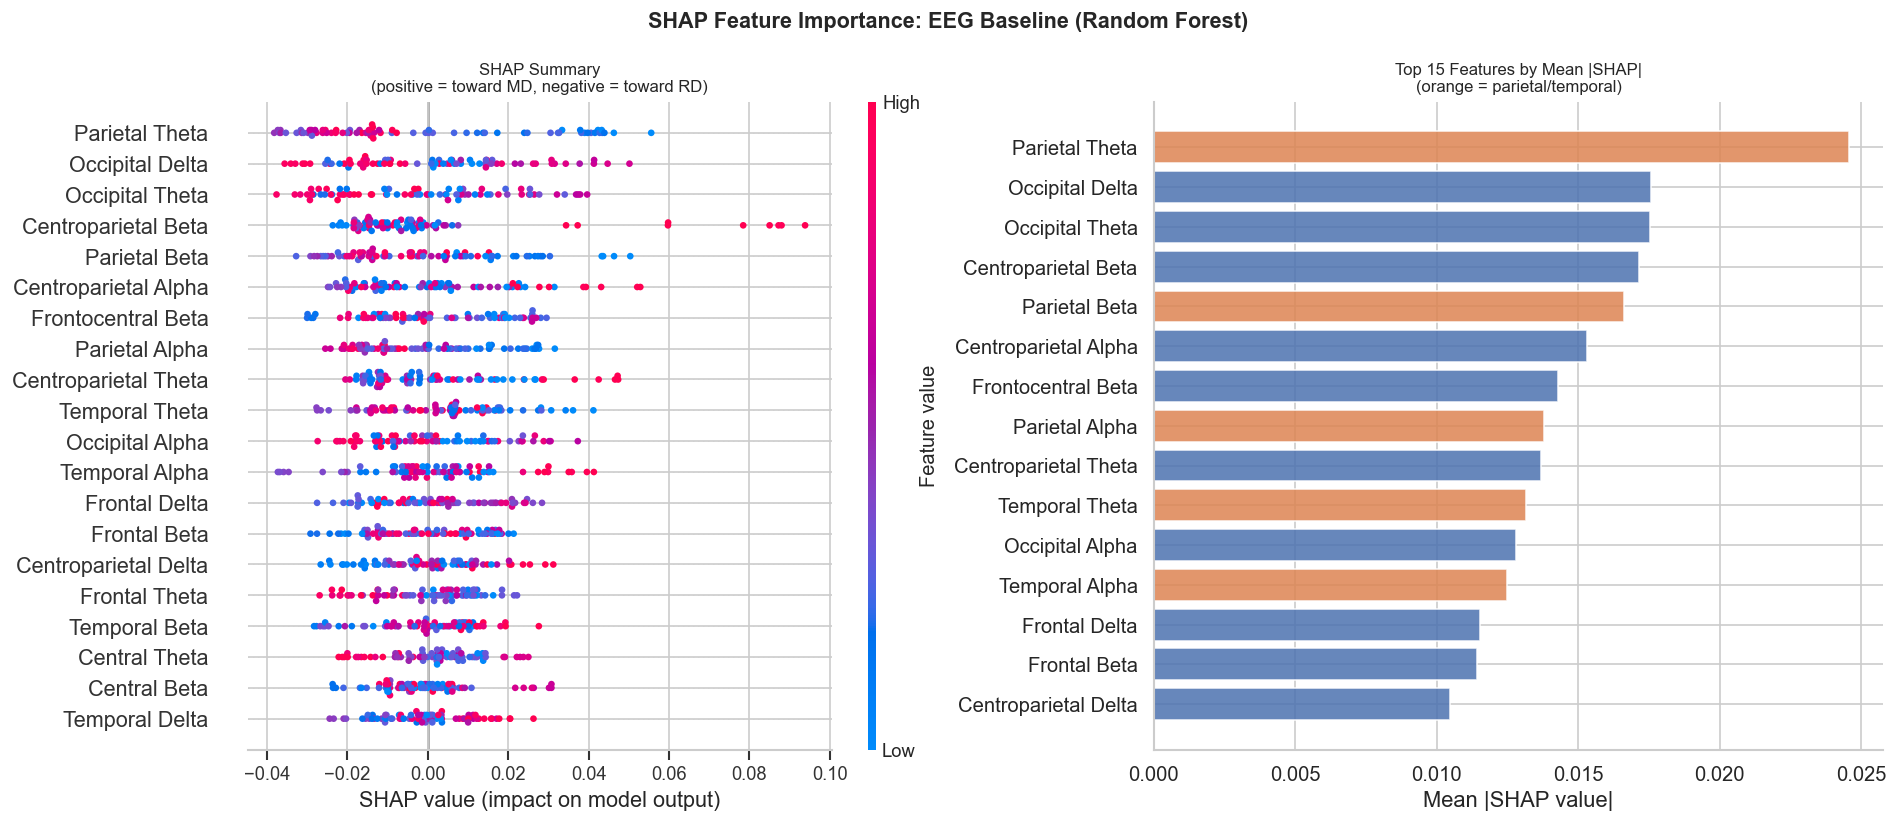

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP Feature Importance: EEG Baseline (Random Forest)',
             fontsize=13, fontweight='bold')

# Left: Summary plot 
plt.sca(axes[0])   
shap.summary_plot(
    sv_md, X_sc,
    feature_names=feat_names,
    plot_type='dot',
    max_display=20,
    show=False,
    plot_size=None
)
axes[0].set_title('SHAP Summary\n(positive = toward MD, negative = toward RD)',
                  fontsize=10)

# Right: Bar chart — top features
top_n = 15
top_feats = [feat_names[i] for i in top_idx[:top_n]]
top_vals = [mean_abs_shap[i] for i in top_idx[:top_n]]
colors_bar = ['#DD8452' if 'Parietal' in f or 'Temporal' in f
              else '#4C72B0' for f in top_feats]
axes[1].barh(top_feats[::-1], top_vals[::-1],
             color=colors_bar[::-1], alpha=0.85)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title(f'Top {top_n} Features by Mean |SHAP|\n(orange = parietal/temporal)',
                  fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '17_shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

Parietal theta is the most discriminative EEG feature (mean |SHAP| = 0.0246), clearly above Occipital Delta (0.0176). This supports the EDA results, where the parietal region showed the largest MD–RD difference across bands. Given the role of parietal cortex in numerical magnitude processing and visuospatial reasoning this result is neuroscientifically interpretable.

Overall, the top features are mainly posterior and inferior: parietal, centroparietal, occipital, and temporal regions. Frontal features appear only at ranks 13–17. This suggests that the model relies more on posterior circuits than on frontal executive networks.

Directionally, high feature values generally increase the prediction toward MD, while low values shift it toward RD. This matches the EDA pattern: MD children show higher absolute EEG power across most region–band combinations.


## 4. SHAP Topographic Projection

SHAP values are projected onto scalp topomaps by assigning each electrode the mean absolute SHAP value of its brain region for each frequency band.

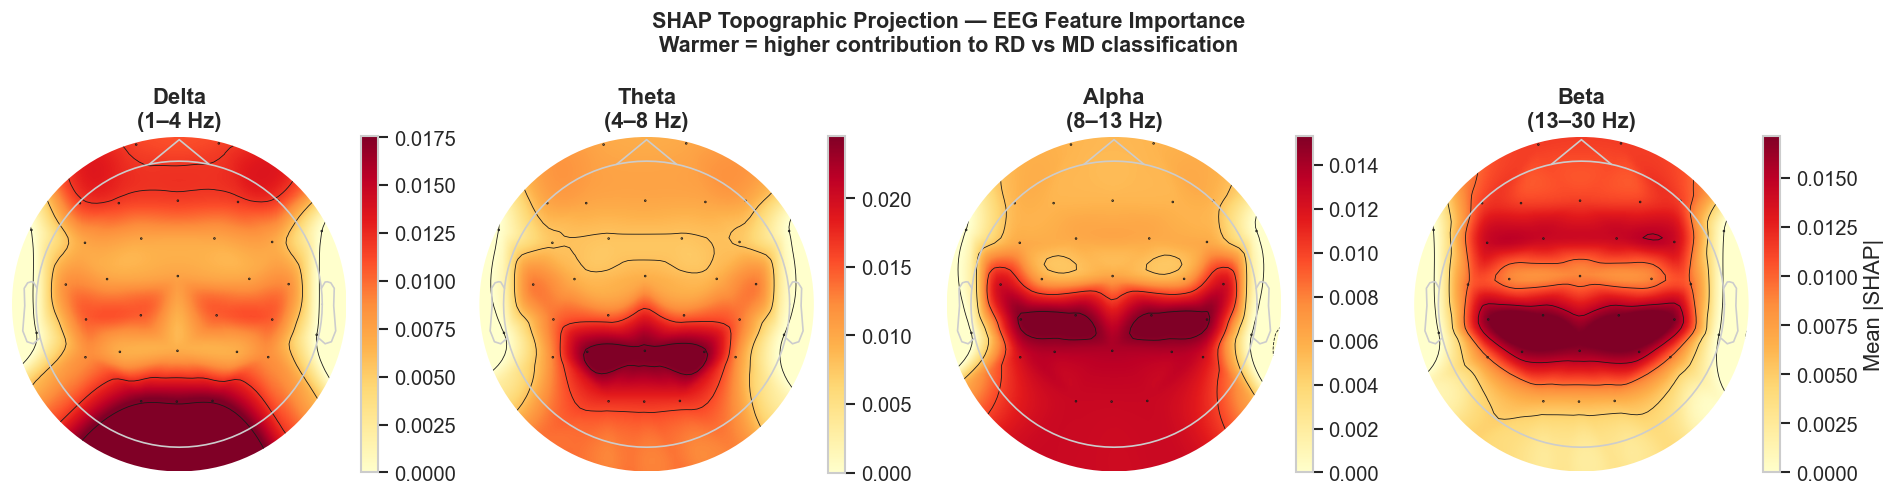

In [32]:
# Channel to region mapping (reverse of preprocessing)
CH_NAMES = ['FP1','FP2','F7','F3','Fz','F4','F8','FT10','FT9','T7',
            'FC5','C3','FC1','FC2','FC6','C4','Cz','CP1','CP5','TP9',
            'CP2','CP6','TP10','T8','P7','P3','Pz','P4','P8','O1','Oz','O2']
REGION_MAP = {
    'frontal': ['FP1','FP2','F3','F4','F7','F8','FZ'],
    'frontocentral': ['FC1','FC2','FC5','FC6'],
    'central': ['C3','C4','CZ'],
    'centroparietal':['CP1','CP2','CP5','CP6'],
    'temporal': ['T7','T8','P7','P8'],
    'parietal': ['P3','P4','PZ'],
    'occipital': ['O1','O2','OZ'],
}
ch_upper = [c.upper() for c in CH_NAMES]

# Feature order: baseline_{region}_{band}
shap_topo = {} 
for band in BANDS:
    ch_shap = np.zeros(32)
    for reg in REGIONS:
        feat_col = f'baseline_{reg}_{band}'
        if feat_col not in EEG_COLS:
            continue
        feat_idx  = EEG_COLS.index(feat_col)
        shap_val  = mean_abs_shap[feat_idx]
        region_chs = [c.upper() for c in REGION_MAP.get(reg, [])]
        for i, ch in enumerate(ch_upper):
            if ch in region_chs:
                ch_shap[i] = shap_val
    shap_topo[band] = ch_shap

# MNE info
info    = mne.create_info(ch_names=CH_NAMES, sfreq=256, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage, match_case=False, on_missing='ignore')

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle('SHAP Topographic Projection — EEG Feature Importance\n'
             'Warmer = higher contribution to RD vs MD classification',
             fontsize=13, fontweight='bold')

for ax, band in zip(axes, BANDS):
    vals = shap_topo[band]
    im, _ = mne.viz.plot_topomap(
        vals, info, axes=ax, show=False,
        cmap='YlOrRd', vlim=(0, vals.max()),
        contours=4, sphere=0.09, extrapolate='head'
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='Mean |SHAP|' if band=='beta' else '')
    lo, hi = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30)}[band]
    ax.set_title(f'{band.capitalize()}\n({lo}–{hi} Hz)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR/'18_shap_topomaps.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:**

The four topomaps show a consistent spatial pattern across all frequency bands: SHAP importance is concentrated in posterior regions (parietal, occipital, and temporal), while frontal areas contribute the least to the classifier’s decisions.

Theta shows the clearest posterior hot zone, especially over parietal and occipital electrodes. This matches the SHAP bar plot, where parietal theta is the top-ranked feature, and supports its role as the main neural discriminator between RD and MD.

Alpha and beta show similar posterior dominant patterns. Alpha highlights parietal–occipital channels, while beta is slightly shifted toward centroparietal and temporal regions, consistent with their high SHAP rankings.

Overall, the topomaps suggest that the RD vs MD distinction in resting-state EEG is mainly driven by posterior cortical activity, especially parietal and occipital circuits related to visuospatial processing, numerical magnitude representation, and visual word-form analysis.



## 5. Gate Value Analysis

The attention-gating model assigns each subject two gate values:
- **α (alpha):** How much the model trusts the EEG modality for this subject
- **β (beta):** How much it trusts the psychometric modality

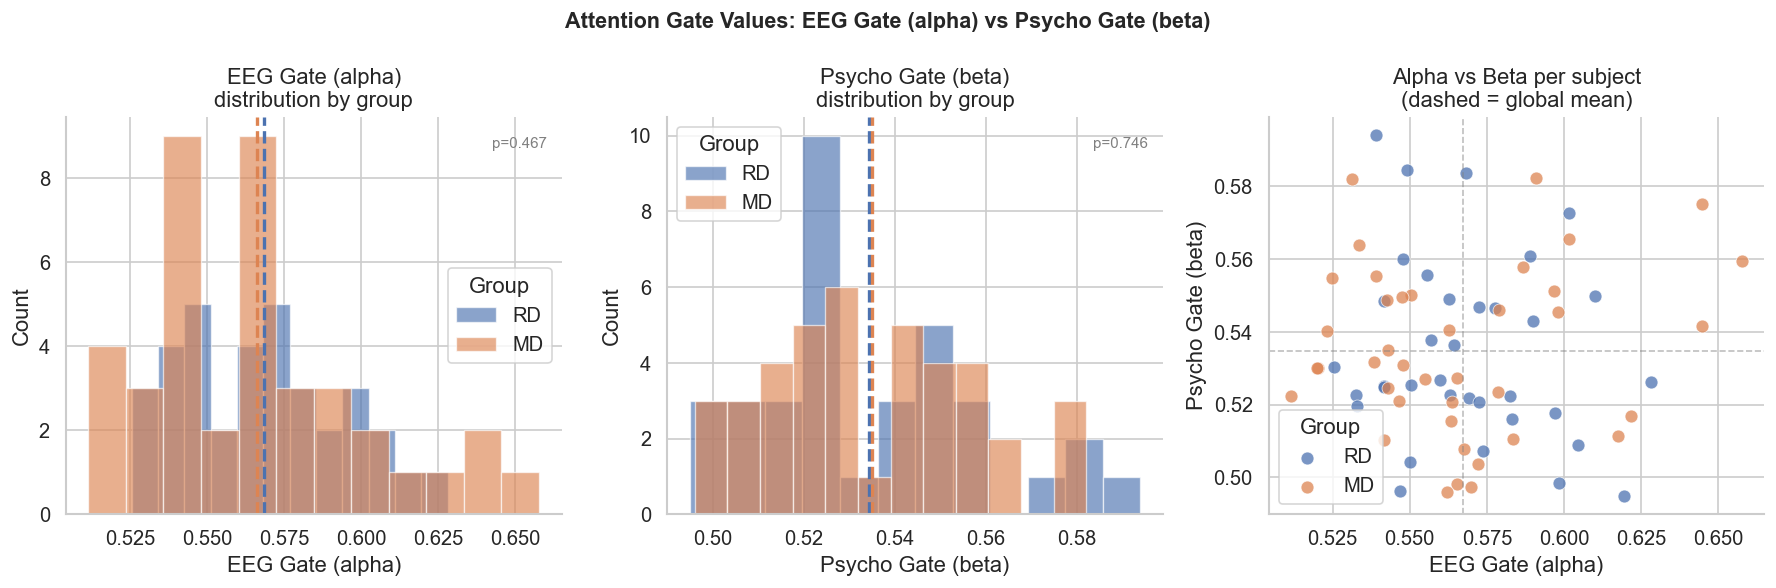


Overall: alpha=0.567 | beta=0.535
EEG gate > Psycho gate: 59/75 subjects


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Attention Gate Values: EEG Gate (alpha) vs Psycho Gate (beta)',
             fontsize=13, fontweight='bold')

# Gate distributions by group
for ax, col, label, color_key in [
    (axes[0], 'alpha_mean', 'EEG Gate (alpha)', 'alpha'),
    (axes[1], 'beta_mean',  'Psycho Gate (beta)', 'beta'),
]:
    for group, color in PALETTE.items():
        vals = gates[gates.label==group][col]
        ax.hist(vals, bins=12, alpha=0.65, color=color, label=group,
                edgecolor='white', linewidth=0.8)
        ax.axvline(vals.mean(), color=color, lw=2, ls='--')
    ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.set_title(f'{label}\ndistribution by group')
    ax.legend(title='Group')
    # Stats
    rd = gates[gates.label=='RD'][col]
    md_g = gates[gates.label=='MD'][col]
    _, p = stats.mannwhitneyu(rd, md_g, alternative='two-sided')
    ax.text(0.97, 0.95, f'p={p:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

# Scatter alpha vs beta per subject
ax3 = axes[2]
for group, color in PALETTE.items():
    sub = gates[gates.label==group]
    ax3.scatter(sub['alpha_mean'], sub['beta_mean'], c=color,
                label=group, alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
ax3.axvline(gates['alpha_mean'].mean(), color='gray', ls='--', lw=1, alpha=0.5)
ax3.axhline(gates['beta_mean'].mean(),  color='gray', ls='--', lw=1, alpha=0.5)
ax3.set_xlabel('EEG Gate (alpha)'); ax3.set_ylabel('Psycho Gate (beta)')
ax3.set_title('Alpha vs Beta per subject\n(dashed = global mean)')
ax3.legend(title='Group')

plt.tight_layout()
plt.savefig(FIG_DIR/'19_gate_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOverall: alpha={gates["alpha_mean"].mean():.3f} | beta={gates["beta_mean"].mean():.3f}')
print(f'EEG gate > Psycho gate: {(gates["alpha_mean"] > gates["beta_mean"]).sum()}/{len(gates)} subjects')

**Interpretation:** 

The three plots show that the attention gating model learned a global modality preference, but not a specific one per group.

The EEG gate is consistently higher than the psychometric gate across both groups (α ≈ 0.567 vs β ≈ 0.534). This means the model gives slightly more weight to EEG than to IQ, attention, and age, which is consistent with EEG being the stronger standalone modality (AUC = 0.555 vs 0.501).

However, neither gate differs significantly between RD and MD.- The histograms largely overlap, and the scatter plot shows RD and MD subjects mixed across the alpha–beta space. Thus, the model does not appear to rely on EEG or psychometrics differently depending on the group.

There is still individual variability, especially in the EEG gate. Some subjects receive much higher EEG weights, suggesting that the model adapts to individual neurocognitive profiles.

Overall, the results suggest that modality weighting is mostly group-independent or that the sample size (n = 75) is too small for the model to learn group-specific gating patterns.



## 6. Hypotheses Validation

| Hypothesis | Focus                         | Status              | Evidence                                                                                                                                                                                                                                |
| ---------- | ----------------------------- | ------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| H1         | Neural differentiation        | Partially confirmed | EEG AUC = 0.555, above chance. The parietal region shows the largest MD–RD difference.<br>Differences are distributed across the scalp rather than focal. |
| H2         | Task modulates neural state   | Confirmed           | Task vs baseline shift is significant in both groups.<br>RD: 3/32 channels significant during reading, suggesting weak engagement.<br>MD: 32/32 channels significant during math, suggesting strong whole-scalp engagement.             |
| H3         | Multimodal fusion outperforms | Confirmed           | Fusion AUC = 0.604 > EEG 0.555 > Shared Psycho 0.501, suggesting that modalities are informationally orthogonal and fusion adds genuine signal.                   |



## 7 · Conclusions & Limitations

This project investigated whether combining EEG spectral features and psychometric scores
improves the classification of children with reading vs mathematical learning difficulties.
Our three main findings were:

**1. Cognitive measures alone are uninformative.** IQ, selective attention, and age
produced poor classification (AUC=0.501), confirming that the groups are matched
on general ability and that their differences are domain-specific.

**2. EEG captures a weak but real neural signal.** Baseline band power features achieved
AUC=0.555, with the parietal region showing the largest and most consistent group differences
across all frequency bands, consistent with the role of posterior parietal cortex in
numerical magnitude processing. 

**3. Multimodal fusion adds value.** The attention-gating model (AUC=0.604, BalAcc=0.577)
outperformed both standalone modalities, confirming H3. The gate values (α≈0.566 for EEG, β≈0.535 for psychometrics) show the model relies slightly more on the neural signal, which aligns with EEG being the stronger standalone modality.

### Limitations

**Sample size (n=75).** The dataset is small for machine learning. 

**No neuroimaging ground truth.** The classification labels (RD vs MD) are based on
behavioural assessments. Neural biomarkers derived here have not been validated against
neuroimaging gold standards.


### Future Directions

- Include EEG task features (shown to have 32/32 significant channels for MD) in the fusion
- Explore larger datasets or data augmentation to stabilise the neural network training
- Validate neural biomarkers against independent neuroimaging data